# EDA — Análisis del Gasto Público en Chile

Este notebook responde las preguntas de negocio definidas en `PROJECT.md`,
usando el dataset ya limpio (`data/processed/ordenes_compra_licitacion_limpio.csv`),
generado en `02_limpieza.ipynb`.

**Fuente de datos:** Órdenes de compra vía licitación, Semestre 1 2026 —
Mercado Público (ChileCompra).

**Nota metodológica:** el dataset original tiene una fila por cada ítem dentro
de una orden de compra (no una fila por orden). Para calcular gasto total, se
usa `drop_duplicates(subset='codigoOC')` para evitar contar el mismo monto de
orden múltiples veces. Para análisis a nivel de producto/categoría, se usa el
dataset completo (a nivel de ítem).

## Preguntas a responder
1. ¿Qué regiones concentran más gasto público?
2. ¿Qué categorías de productos/servicios se compran más?
3. ¿Existe estacionalidad en el gasto?
4. ¿Qué organismos son los que más compran?

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/ordenes_compra_licitacion_limpio.csv', parse_dates=['FechaEnvioOC'])
df.shape

(28034, 48)

In [16]:
gasto_por_orden = df.drop_duplicates(subset='codigoOC')[['codigoOC', 'RegionUnidadCompra', 'MontoNetoOC_final']]
gasto_por_orden.shape

(10099, 3)

In [17]:
df.columns.tolist()

['codigoOC',
 'NroLicitacion',
 'FechaEnvioOC',
 'NombreOC',
 'DescripcionOC',
 'EstadoOC',
 'ProcedenciaOC',
 'CompraCoordinada',
 'MonedaOC',
 'MontoNetoOC',
 'DescuentosOC',
 'CargosOC',
 'ImpuestosOC',
 'MontoTotalOC',
 'ImpuestosOC_CLP',
 'MontoNetoOC_CLP',
 'MetodoPago',
 'TipoDespacho',
 'UnidadCompra',
 'UnidadCompraRUT',
 'RegionUnidadCompra',
 'entCode',
 'Institucion',
 'Sector',
 'Proveedor',
 'ProveedorRUT',
 'ActividadProveedor',
 'TamanoProveedor',
 'RegionProveedor',
 'RubroN1',
 'RubroN2',
 'RubroN3',
 'CodigoProductoONU',
 'ONUProducto',
 'NombreItem',
 'DescripcionItem',
 'CantidadItem',
 'UnidadMedida',
 'MonedaItem',
 'MontoNetoItem',
 'DescuentoItem',
 'CargosItem',
 'ImpuestoEspecificoItem',
 'MontoTotalItem',
 'MontoNetoItemCLP',
 'MontoNetoOC_final',
 'ImpuestosOC_final',
 'MontoNetoItem_final']

In [18]:
gasto_por_region_millones = (gasto_por_region / 1_000_000).round(1)
gasto_por_region_millones

RegionUnidadCompra
Region Metropolitana de Santiago                    65807.5
Region de Valparaiso                                12539.4
Region de la Araucania                              11656.6
Region de Tarapaca                                   8927.7
Region del Maule                                     7164.2
Region del Libertador General Bernardo OHiggins      6918.6
Region de Atacama                                    6783.0
Region del Biobio                                    6654.6
Region del Nuble                                     5181.2
Region de Los Rios                                   4926.1
Region de Coquimbo                                   4451.0
Region de Magallanes y de la Antartica               4424.5
Region Aysen del General Carlos IbaNez del Campo     4359.4
Region de los Lagos                                  3781.6
Region de Antofagasta                                3061.2
Region de Arica y Parinacota                         2730.1
Nacional / Multiples 

## Pregunta 1: Distribución geográfica del gasto

¿Qué regiones concentran más gasto público?

Se agrupan las órdenes de compra (evitando duplicar montos por ítem) y se
suma el gasto total por región.

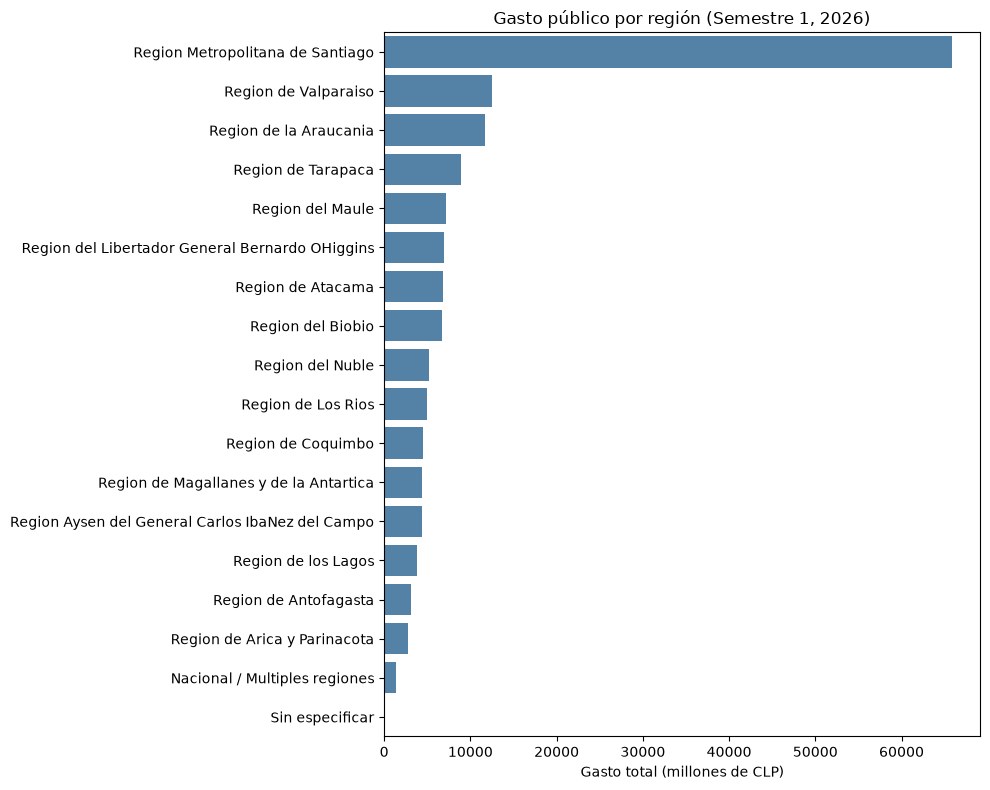

In [19]:
plt.figure(figsize=(10, 8))
sns.barplot(x=gasto_por_region_millones.values, y=gasto_por_region_millones.index, color='steelblue')
plt.xlabel('Gasto total (millones de CLP)')
plt.ylabel('')
plt.title('Gasto público por región (Semestre 1, 2026)')
plt.tight_layout()
plt.show()

**Hallazgo:** La Región Metropolitana concentra el mayor gasto público
($65.807 millones), más de 5 veces el monto de la segunda región
(Valparaíso, $12.539 millones). Esto es esperable dado que gran parte de
los organismos centrales del Estado tienen su sede en la RM. El resto de
las regiones muestra una caída gradual, sin otro quiebre tan marcado.

## Pregunta 2: Categorías de productos/servicios más compradas

¿Qué categorías (RubroN1) concentran más gasto?

A diferencia de la Pregunta 1, acá se usa el dataset completo a nivel de
ítem (sin agrupar por orden), ya que el análisis es sobre productos
individuales, no sobre el total de cada orden.

In [20]:
gasto_por_rubro = df.groupby('RubroN1')['MontoNetoItem_final'].sum().sort_values(ascending=False)
gasto_por_rubro_millones = (gasto_por_rubro / 1_000_000).round(1).head(10)

gasto_por_rubro_millones

RubroN1
Servicios de defensa nacional, orden público y seguridad                          41042.1
Servicios de construcción y mantenimiento                                         22139.5
Servicios de transporte, almacenaje y correo                                      17085.2
Servicios de limpieza industrial                                                   9700.4
Servicios profesionales, administrativos y consultorías de gestión empresarial     8333.9
Tecnologías de la información, telecomunicaciones y radiodifusión                  7871.7
Equipamiento y suministros médicos                                                 5939.2
Salud, servicios sanitarios y alimentación                                         4212.6
Servicios básicos y de información pública                                         3338.9
Servicios de Viajes, alimentación, alojamiento y entretenimiento                   3241.8
Name: MontoNetoItem_final, dtype: float64

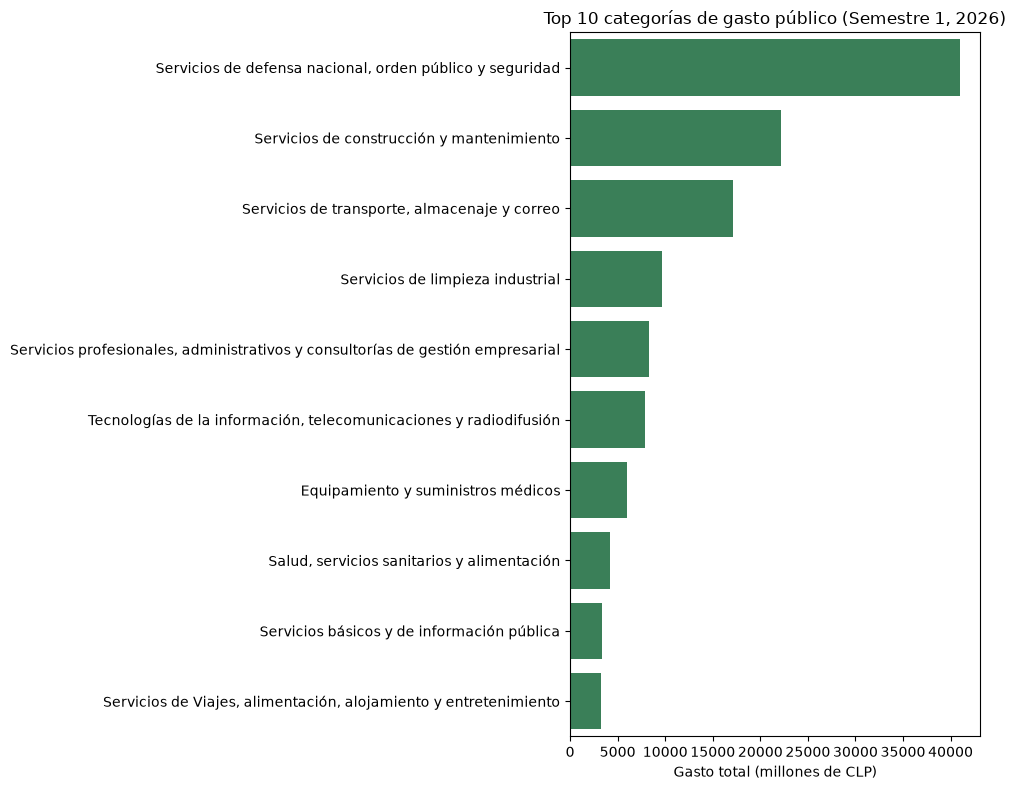

In [21]:
plt.figure(figsize=(10, 8))
sns.barplot(x=gasto_por_rubro_millones.values, y=gasto_por_rubro_millones.index, color='seagreen')
plt.xlabel('Gasto total (millones de CLP)')
plt.ylabel('')
plt.title('Top 10 categorías de gasto público (Semestre 1, 2026)')
plt.tight_layout()
plt.show()

**Hallazgo:** La categoría "Servicios de defensa nacional, orden público y
seguridad" concentra el mayor gasto ($41.042 millones), casi el doble que
la segunda categoría ("Servicios de construcción y mantenimiento",
$22.139 millones). Le siguen transporte/almacenaje/correo ($17.085
millones) y limpieza industrial ($9.700 millones).

Resulta interesante notar que categorías de salud (equipamiento médico,
servicios sanitarios) aparecen en el top 10, pero considerablemente por
debajo de seguridad y construcción — un posible punto de comparación
para profundizar en un análisis futuro sobre priorización presupuestaria.

## Pregunta 3: Estacionalidad del gasto

¿Existen patrones de estacionalidad en el gasto público?

Nota: al contar únicamente con datos del Semestre 1 2026 (enero-junio), el
análisis se limita a la distribución del gasto mes a mes dentro de este
período, sin poder evaluar patrones estacionales año contra año.

Se agrupan las órdenes de compra (evitando duplicar montos por ítem) y se
extrae el mes de cada orden a partir de FechaEnvioOC.

In [ ]:
gasto_por_orden_fecha = df.drop_duplicates(subset='codigoOC')[['codigoOC', 'FechaEnvioOC', 'MontoNetoOC_final']]
gasto_por_orden_fecha['mes'] = gasto_por_orden_fecha['FechaEnvioOC'].dt.month
gasto_por_orden_fecha.head()

,codigoOC,FechaEnvioOC,MontoNetoOC_final,mes
0,1216058-134-SE25,2026-03-16,35268.9,3
1,1233623-277-SE25,2026-02-05,6602000.0,2
2,1216085-500-SE25,2026-03-23,2180613.1,3
5,1171142-3945-SE25,2026-01-16,4207516.0,1
6,1171142-3935-SE25,2026-01-16,288944.0,1


In [23]:
gasto_por_mes = gasto_por_orden_fecha.groupby('mes')['MontoNetoOC_final'].sum()
gasto_por_mes_millones = (gasto_por_mes / 1_000_000).round(1)
gasto_por_mes_millones

mes
1    22165.7
2    46020.6
3    38449.5
4    29428.9
5    24650.1
Name: MontoNetoOC_final, dtype: float64

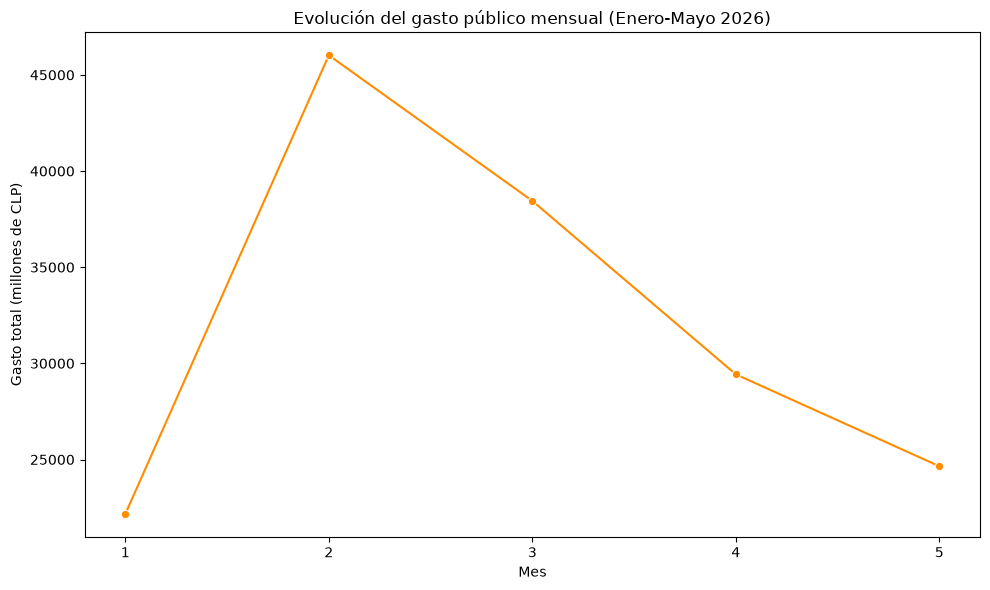

In [26]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=gasto_por_mes_millones.index, y=gasto_por_mes_millones.values, marker='o', color='darkorange')
plt.xlabel('Mes')
plt.ylabel('Gasto total (millones de CLP)')
plt.title('Evolución del gasto público mensual (Enero-Mayo 2026)')
plt.xticks(range(1, 6))
plt.tight_layout()
plt.show()

In [27]:
gasto_por_orden_fecha['FechaEnvioOC'].max()

Timestamp('2026-05-31 00:00:00')

**Hallazgo:** El gasto público muestra un pico marcado en febrero ($46.021
millones), más del doble que enero ($22.166 millones), seguido de una caída
sostenida hasta mayo ($24.650 millones).

**Nota metodológica:** el dataset solo contiene datos hasta el 31 de mayo de
2026 (no incluye junio), consistente con el desfase de actualización
mencionado en el portal de datos abiertos de ChileCompra. Por lo tanto, no
se puede evaluar el semestre completo, y esta caída hacia mayo podría
continuar o revertirse en junio — no hay datos suficientes para confirmarlo.

Sería interesante, en un análisis futuro con datos de años anteriores,
confirmar si el pico de febrero-marzo es un patrón recurrente (por ejemplo,
asociado al inicio del año escolar/fiscal) o específico de este semestre.

## Pregunta 4: Concentración institucional

¿Qué organismos son los que más compran?

Se agrupan las órdenes de compra (evitando duplicar montos por ítem) y se
suma el gasto total por institución.

In [28]:
gasto_por_institucion = gasto_por_orden.merge(df[['codigoOC', 'Institucion']].drop_duplicates(), on='codigoOC')
gasto_por_institucion = gasto_por_institucion.groupby('Institucion')['MontoNetoOC_final'].sum().sort_values(ascending=False)
gasto_por_institucion_millones = (gasto_por_institucion / 1_000_000).round(1).head(10)
gasto_por_institucion_millones

Institucion
SERVICIO NACIONAL DE REINSERCION SOCIAL JUVENIL                           42439.5
FUNDACION EDUCACIONAL PARA EL DESAROLLO INTEGRAL DE LA NIÑEZ              11534.6
CORP MUNIC EDUC SALUD Y ATENCION                                           9025.9
SERVICIO NACIONAL DE PROTECCIÓN ESPECIALIZADA A LA NIÑEZ Y ADOLESCENCI     7343.9
HOSPITAL COMPLEJO ASISTENCIAL PADRE LAS CASAS                              6101.5
SERVICIO LOCAL DE EDUCACION PÚBLICA DE ATACAMA                             5539.0
SERVICIO LOCAL DE EDUCACIÓN PÚBLICA MAULE COSTA                            4765.8
SERVICIO LOCAL DE EDUCACIÓN PÚBLICA DE VALDIVIA                            3950.8
Servicio Local de Educación Pública Punilla Cordillera                     3525.1
Servicio Local de Educación Pública Iquique                                3459.3
Name: MontoNetoOC_final, dtype: float64

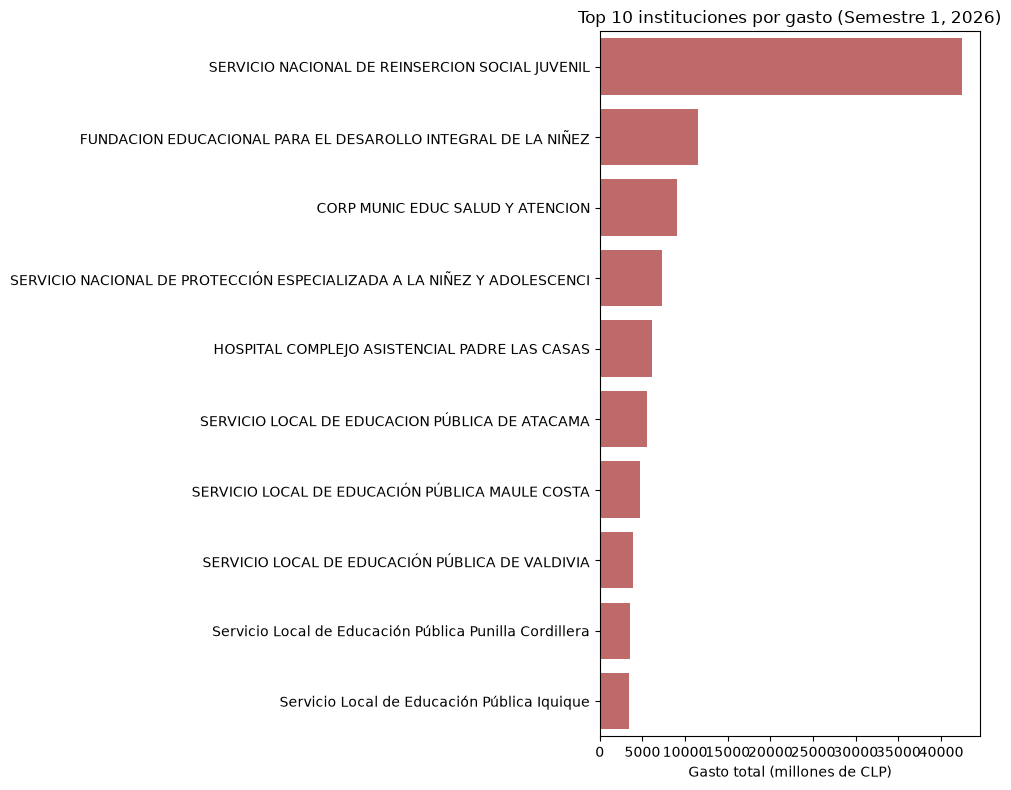

In [29]:
plt.figure(figsize=(10, 8))
sns.barplot(x=gasto_por_institucion_millones.values, y=gasto_por_institucion_millones.index, color='indianred')
plt.xlabel('Gasto total (millones de CLP)')
plt.ylabel('')
plt.title('Top 10 instituciones por gasto (Semestre 1, 2026)')
plt.tight_layout()
plt.show()

**Hallazgo:** El Servicio Nacional de Reinserción Social Juvenil concentra
el mayor gasto individual ($42.439 millones), casi 4 veces más que la
segunda institución del ranking. El top 10 está dominado por organismos
vinculados a educación (Servicios Locales de Educación Pública) y
protección de la niñez/adolescencia.

Es interesante notar que este top 10 difiere bastante del ranking por
categoría de producto (Pregunta 2), donde dominaba "defensa y seguridad".
Esto sugiere que el gasto en seguridad está distribuido entre pocos
organismos con compras grandes (FFAA, Carabineros), mientras que
instituciones como los Servicios Locales de Educación, aunque individualmente
compran menos por transacción, aparecen concentradas en este ranking por
volumen